---
numbering: false
---

# 2.1. Overview

## Introduction

The time has finally come: let's apply what we've learned about loss functions and the modeling recipe to "upgrade" from the constant model to the simple linear regression model.

To recap, our goal is to find a hypothesis function $h$ such that:

$$\text{predicted commute time}_i = h(\text{departure hour}_i)$$

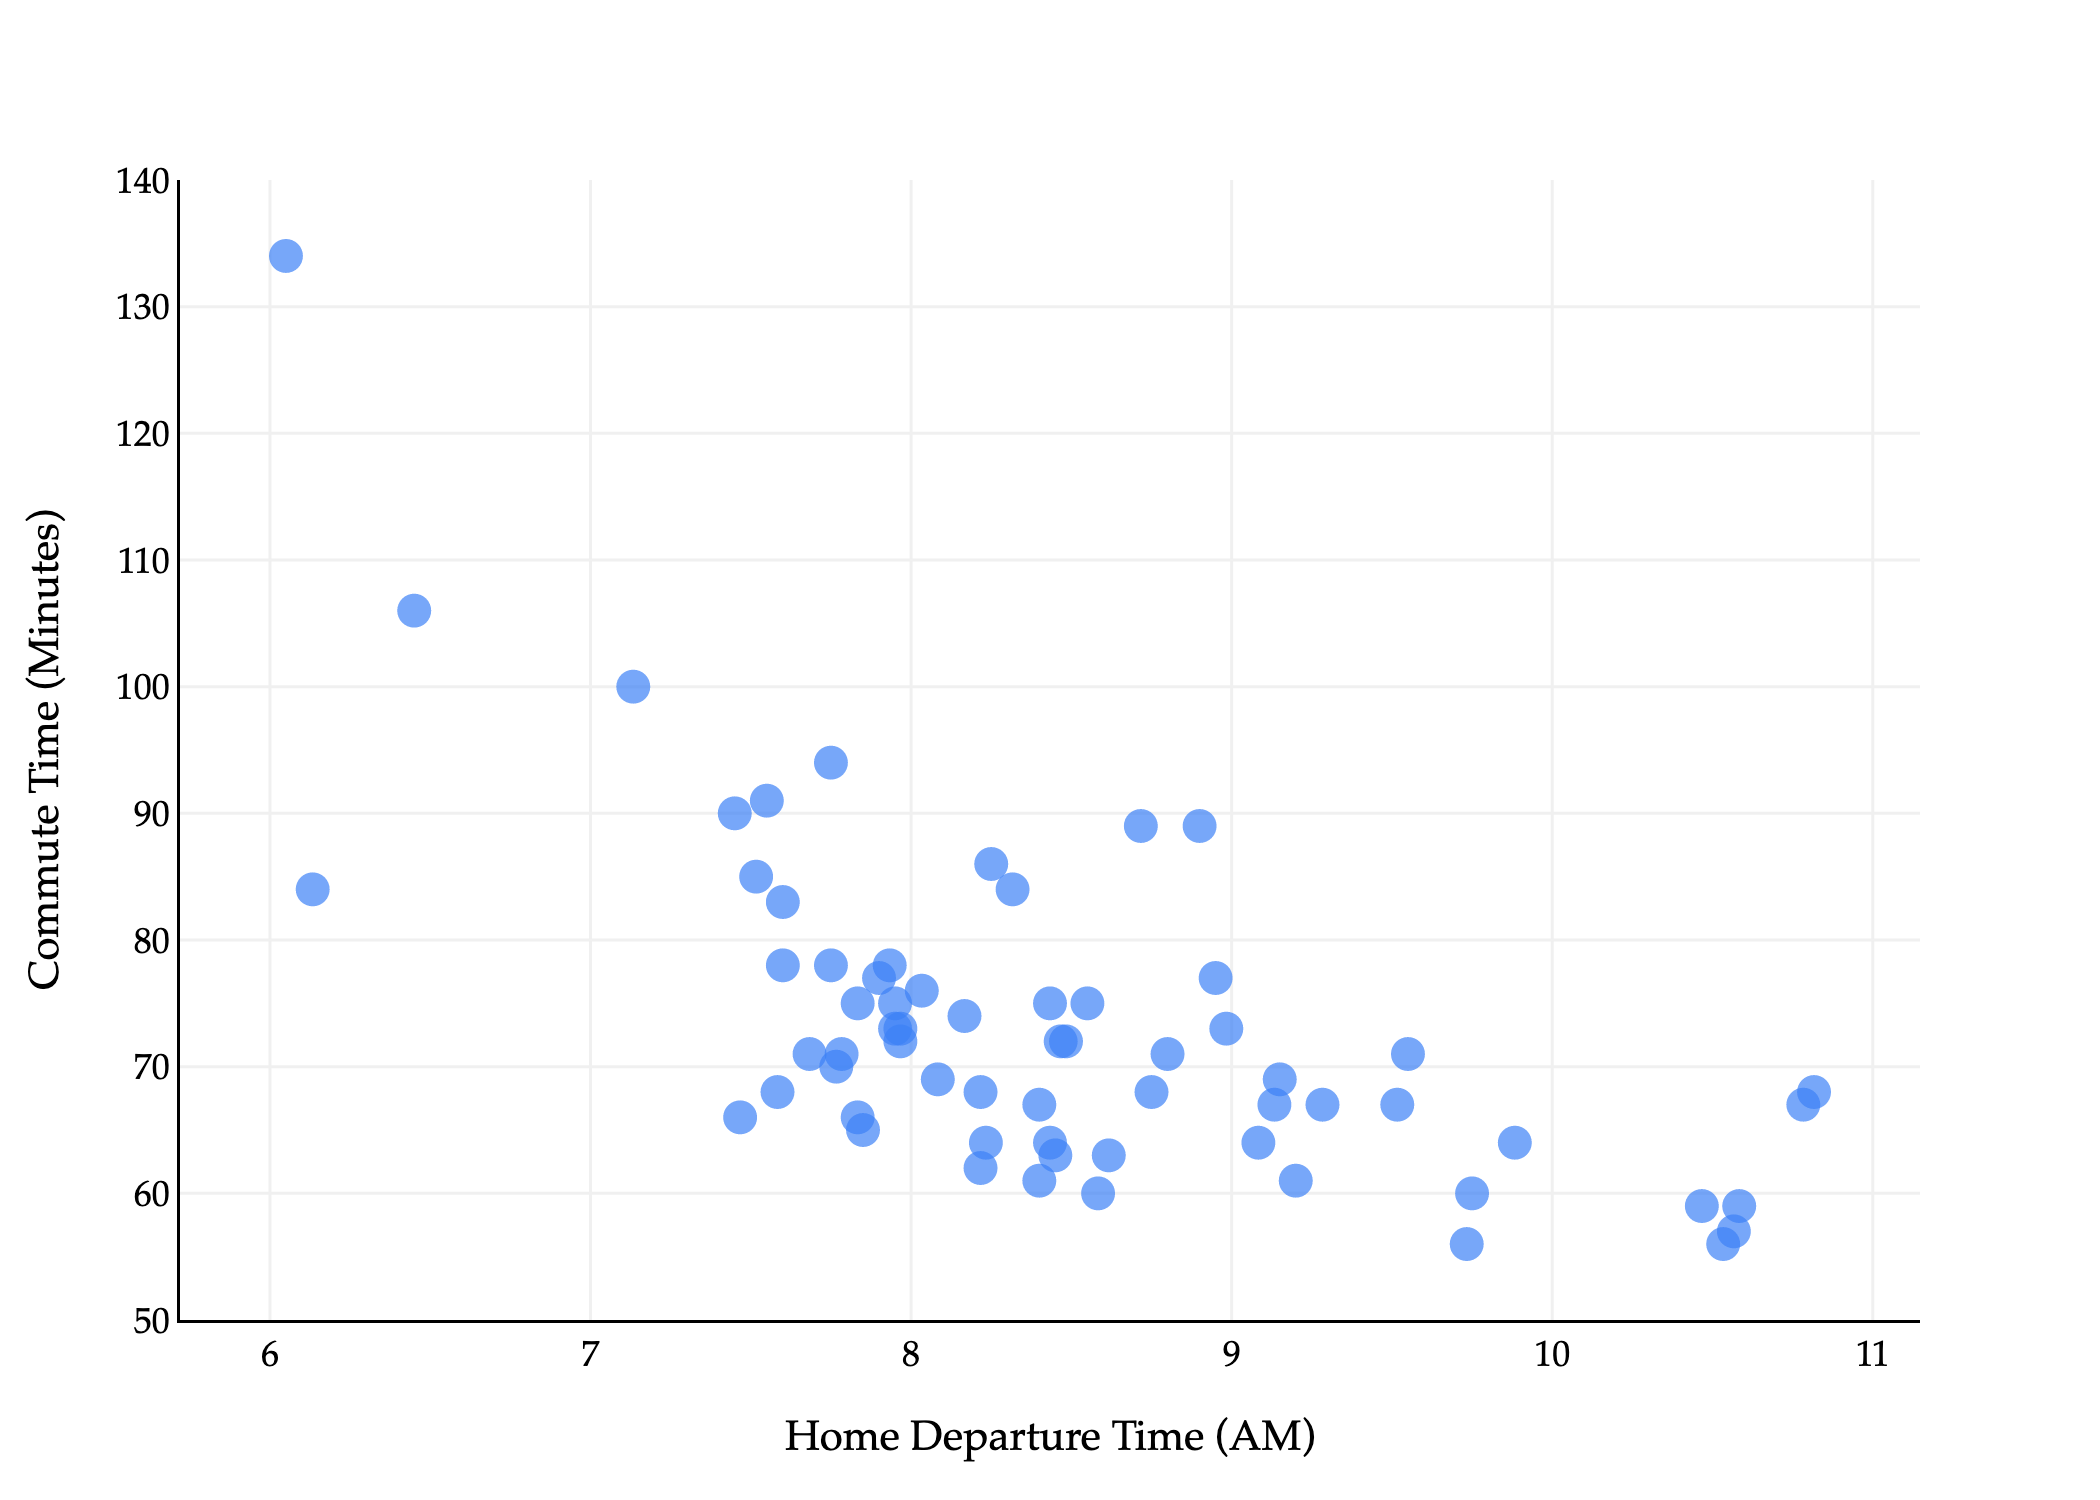

In [304]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv('data/commute-times.csv')

fig = px.scatter(
    df,
    x='departure_hour',
    y='minutes',
    size=np.ones(len(df)) * 50,
    size_max=8
)
fig.update_xaxes(
    title='Home Departure Time (AM)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    title='Commute Time (Minutes)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)
fig.show(renderer='png', scale=3)

So far, we've studied the constant model, where the hypothesis function is a horizontal line:

$$h(x_i) = w$$

The sole parameter, $w$, controlled the height of the line. Up until now, "parameter" and "prediction" were interchangeable terms, because our sole parameter $w$ controlled what our constant prediction was.

Now, the simple linear regression model has two parameters:

$$h(x_i) = w_0 + w_1 x_i$$

$w_0$ controls the intercept of the line, and $w_1$ controls its slope. No longer is it the case that "parameter" and "prediction" are interchangeable terms, because $w_0$ and $w_1$ control different aspects of the prediction-making process.

**How do we find the optimal parameters, $w_0^*$ and $w_1^*$?** Different values of $w_0$ and $w_1$ give us different lines, each of which fit the data with varying degrees of accuracy.

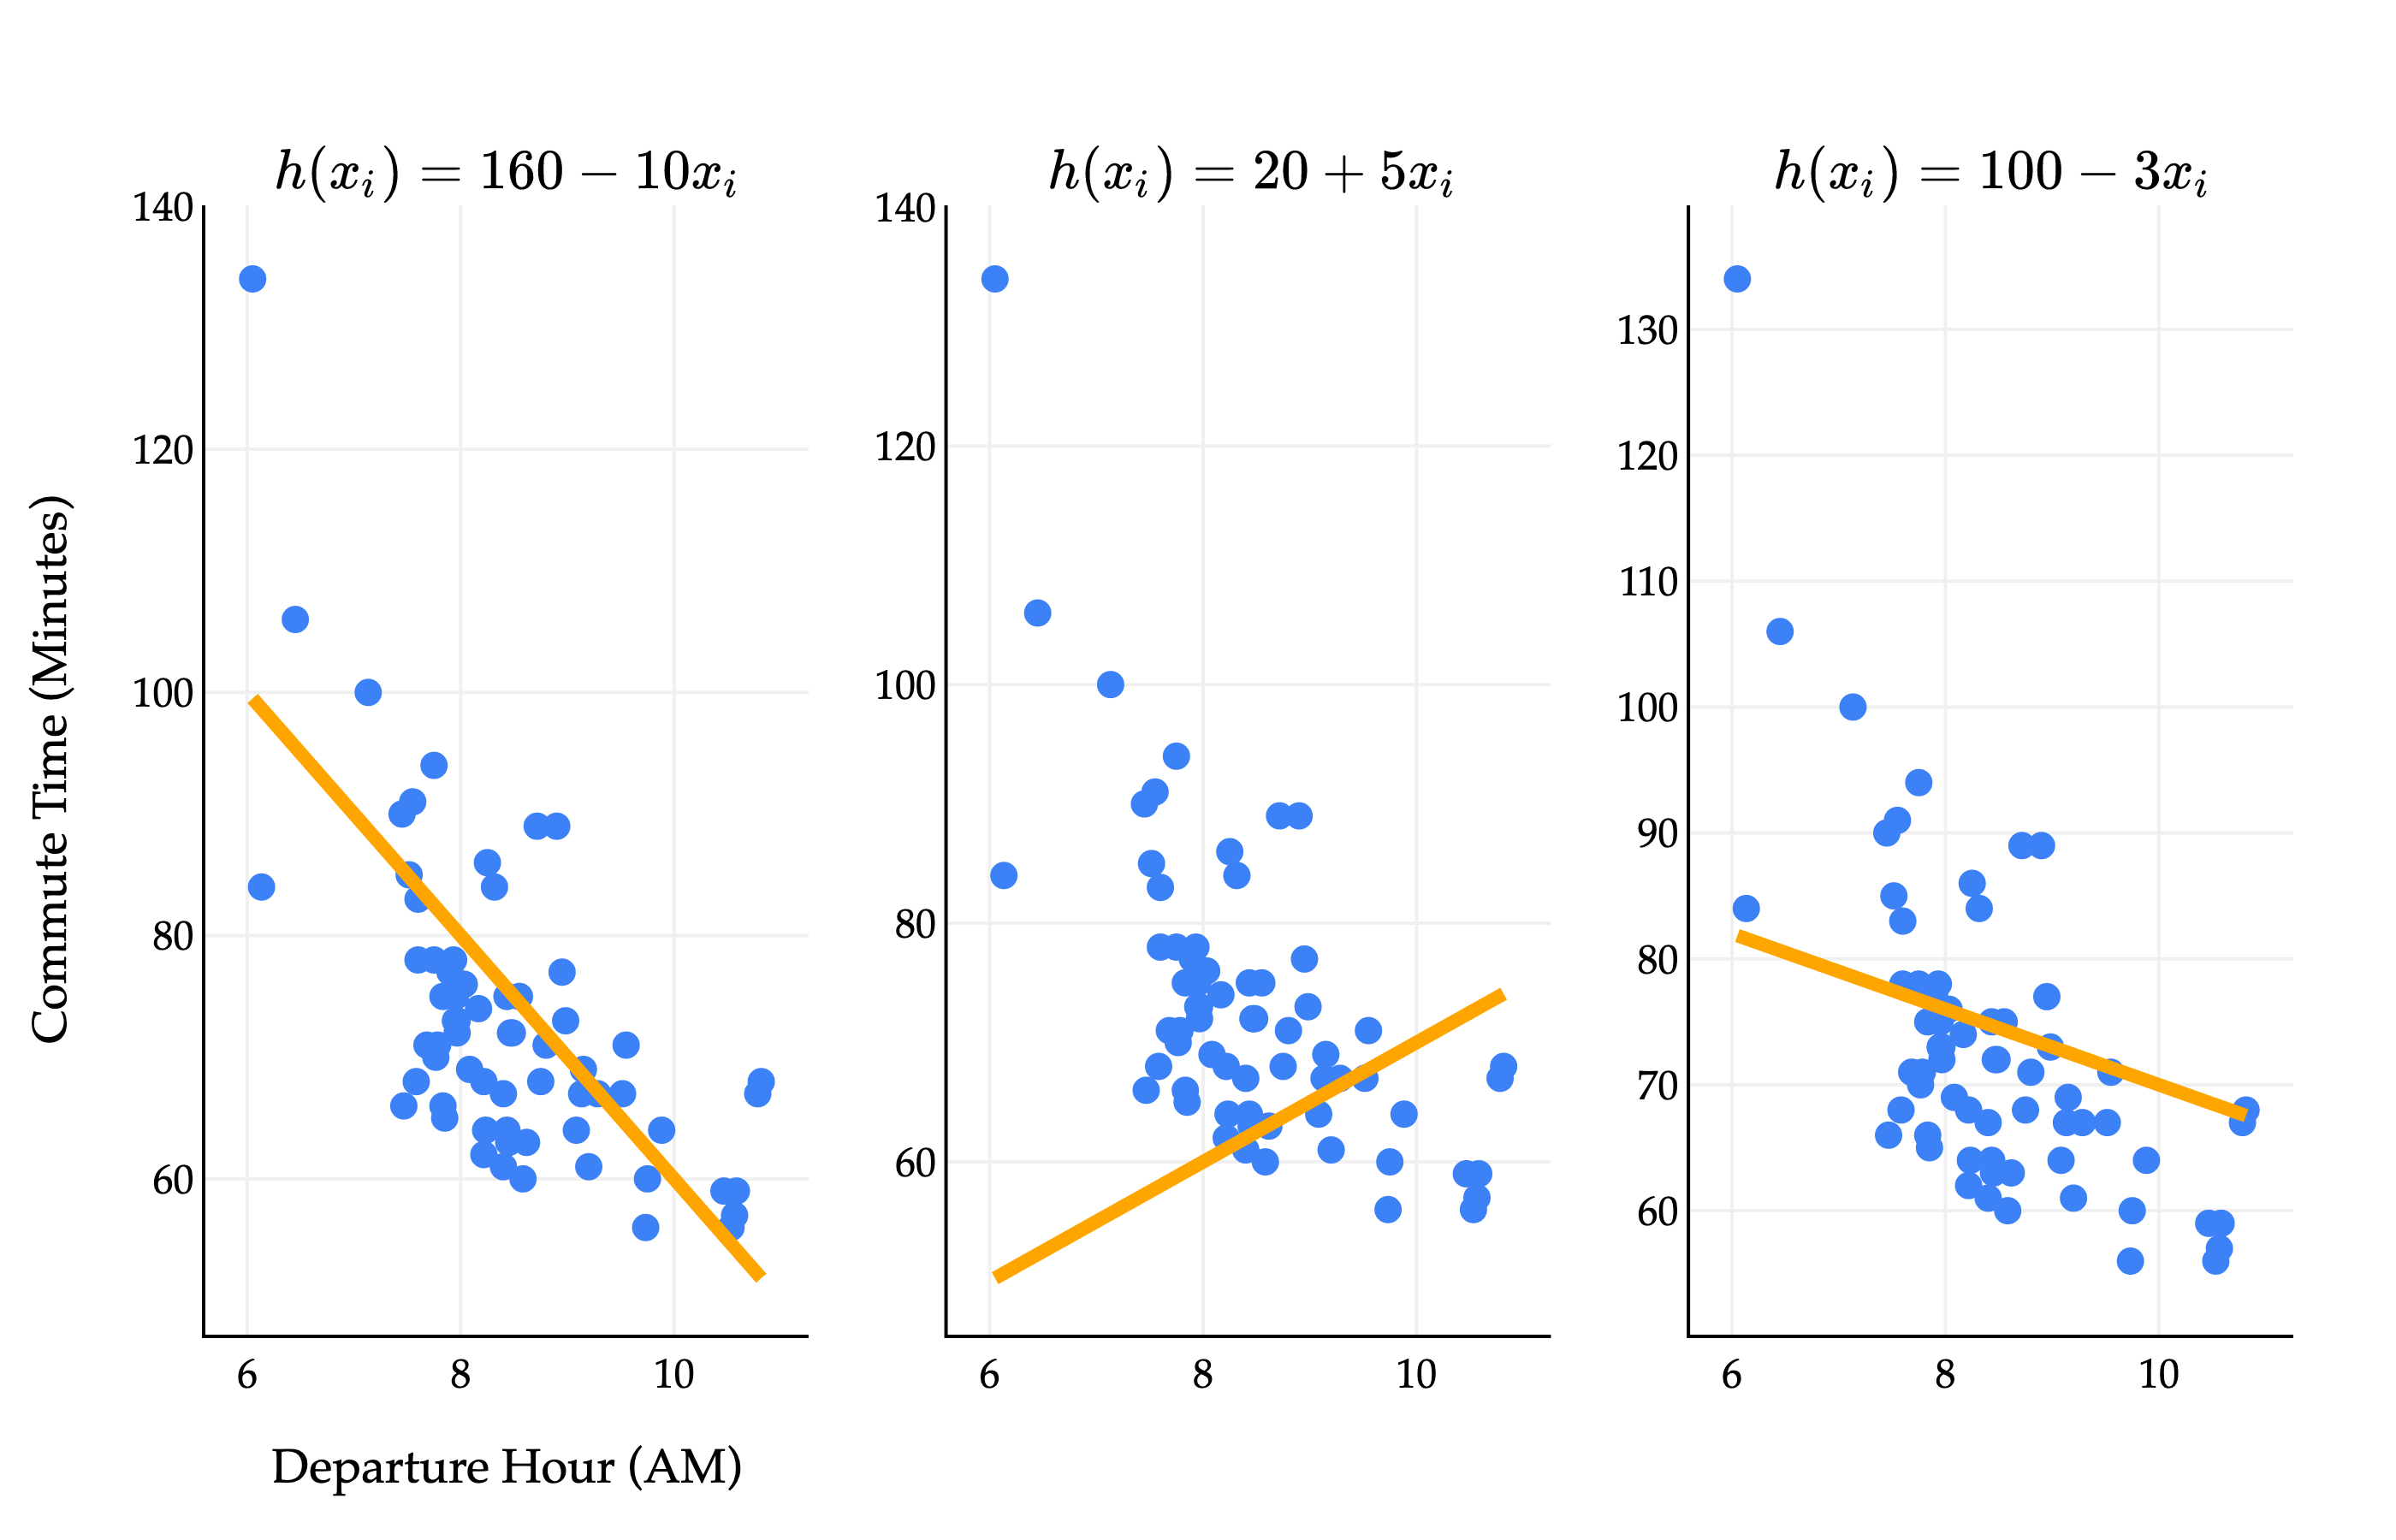

In [305]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('data/commute-times.csv')

x = df['departure_hour'].values
y = df['minutes'].values

# Define (slope, intercept) pairs for three lines
lines = [
    (-10, 160),      # h(x) = 70
    (5, 20),      # h(x) = 5x + 20
    (-3, 100)     # h(x) = -3x + 100
]

# Titles for each subplot
subplot_titles = [
    r"$h(x_i) = 160 - 10x_i$",
    r"$h(x_i) = 20 + 5x_i$",
    r"$h(x_i) = 100 - 3x_i$"
]

fig = make_subplots(rows=1, cols=3, subplot_titles=subplot_titles)

x_line = np.linspace(x.min(), x.max(), 100)

for i, (slope, intercept) in enumerate(lines, start=1):
    fig.add_trace(
        go.Scatter(
            x=x, 
            y=y, 
            mode='markers', 
            name='Data', 
            marker=dict(
                color='#3D81F6', 
                size=8,
            ),
            showlegend=False
        ),
        row=1, col=i
    )

    y_line = slope * x_line + intercept
    fig.add_trace(
        go.Scatter(
            x=x_line, 
            y=y_line, 
            mode='lines', 
            name=f'$h(x)={slope}x+{intercept}$', 
            line=dict(color='orange', width=4)
        ),
        row=1, col=i
    )

fig.update_layout(
    showlegend=False,
    xaxis_title='Departure Hour (AM)',
    yaxis_title='Commute Time (Minutes)',
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=700,
    height=450,
    legend=dict(
        bgcolor='rgba(0,0,0,0)',
        bordercolor='rgba(0,0,0,0)',
        font=dict(size=14)
    ),
    margin=dict(l=60, r=30, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)

fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.show(renderer='png', scale=4)

:::{tip} Activity 1
:class: dropdown

Consider a dataset with two points, $(3, 5)$ and $(15, 53)$. What are the optimal parameters, $w_0^*$ and $w_1^*$, for the line $h(x_i) = w_0 + w_1 x_i$ that minimizes mean squared error for this dataset?
:::

To make things precise, let's turn to the three-step modeling recipe from [Chapter 1.3](../01_introduction_to_supervised_learning/03-absolute-loss.ipynb).

**1. Choose a model.**

$$h(x_i) = w_0 + w_1 x_i$$

**2. Choose a loss function.**

We'll stick with squared loss:

$$L_\text{sq}(y_i, h(x_i)) = (y_i - h(x_i))^2$$

**3. Minimize average loss (also known as empirical risk) to find optimal parameters.**

Average squared loss – also known as mean squared error – for any hypothesis function $h$, takes the form:

$$\frac{1}{n} \sum_{i=1}^n (y_i - h(x_i))^2$$

For the simple linear regression model, this becomes:

$$R_\text{sq}(w_0, w_1) = \frac{1}{n} \sum_{i=1}^n (y_i - (w_0 + w_1 x_i))^2$$

Now, we need to find the values of $w_0$ and $w_1$ that together minimize $R_\text{sq}(w_0, w_1)$. But what does that even mean?

In the case of the context model and squared loss, where we had to minimize $ R_\text{sq}(w) = \frac{1}{n} \sum_{i=1}^n (y_i - w)^2$, we did so by taking the derivative with respect to $w$ and setting it to 0. 

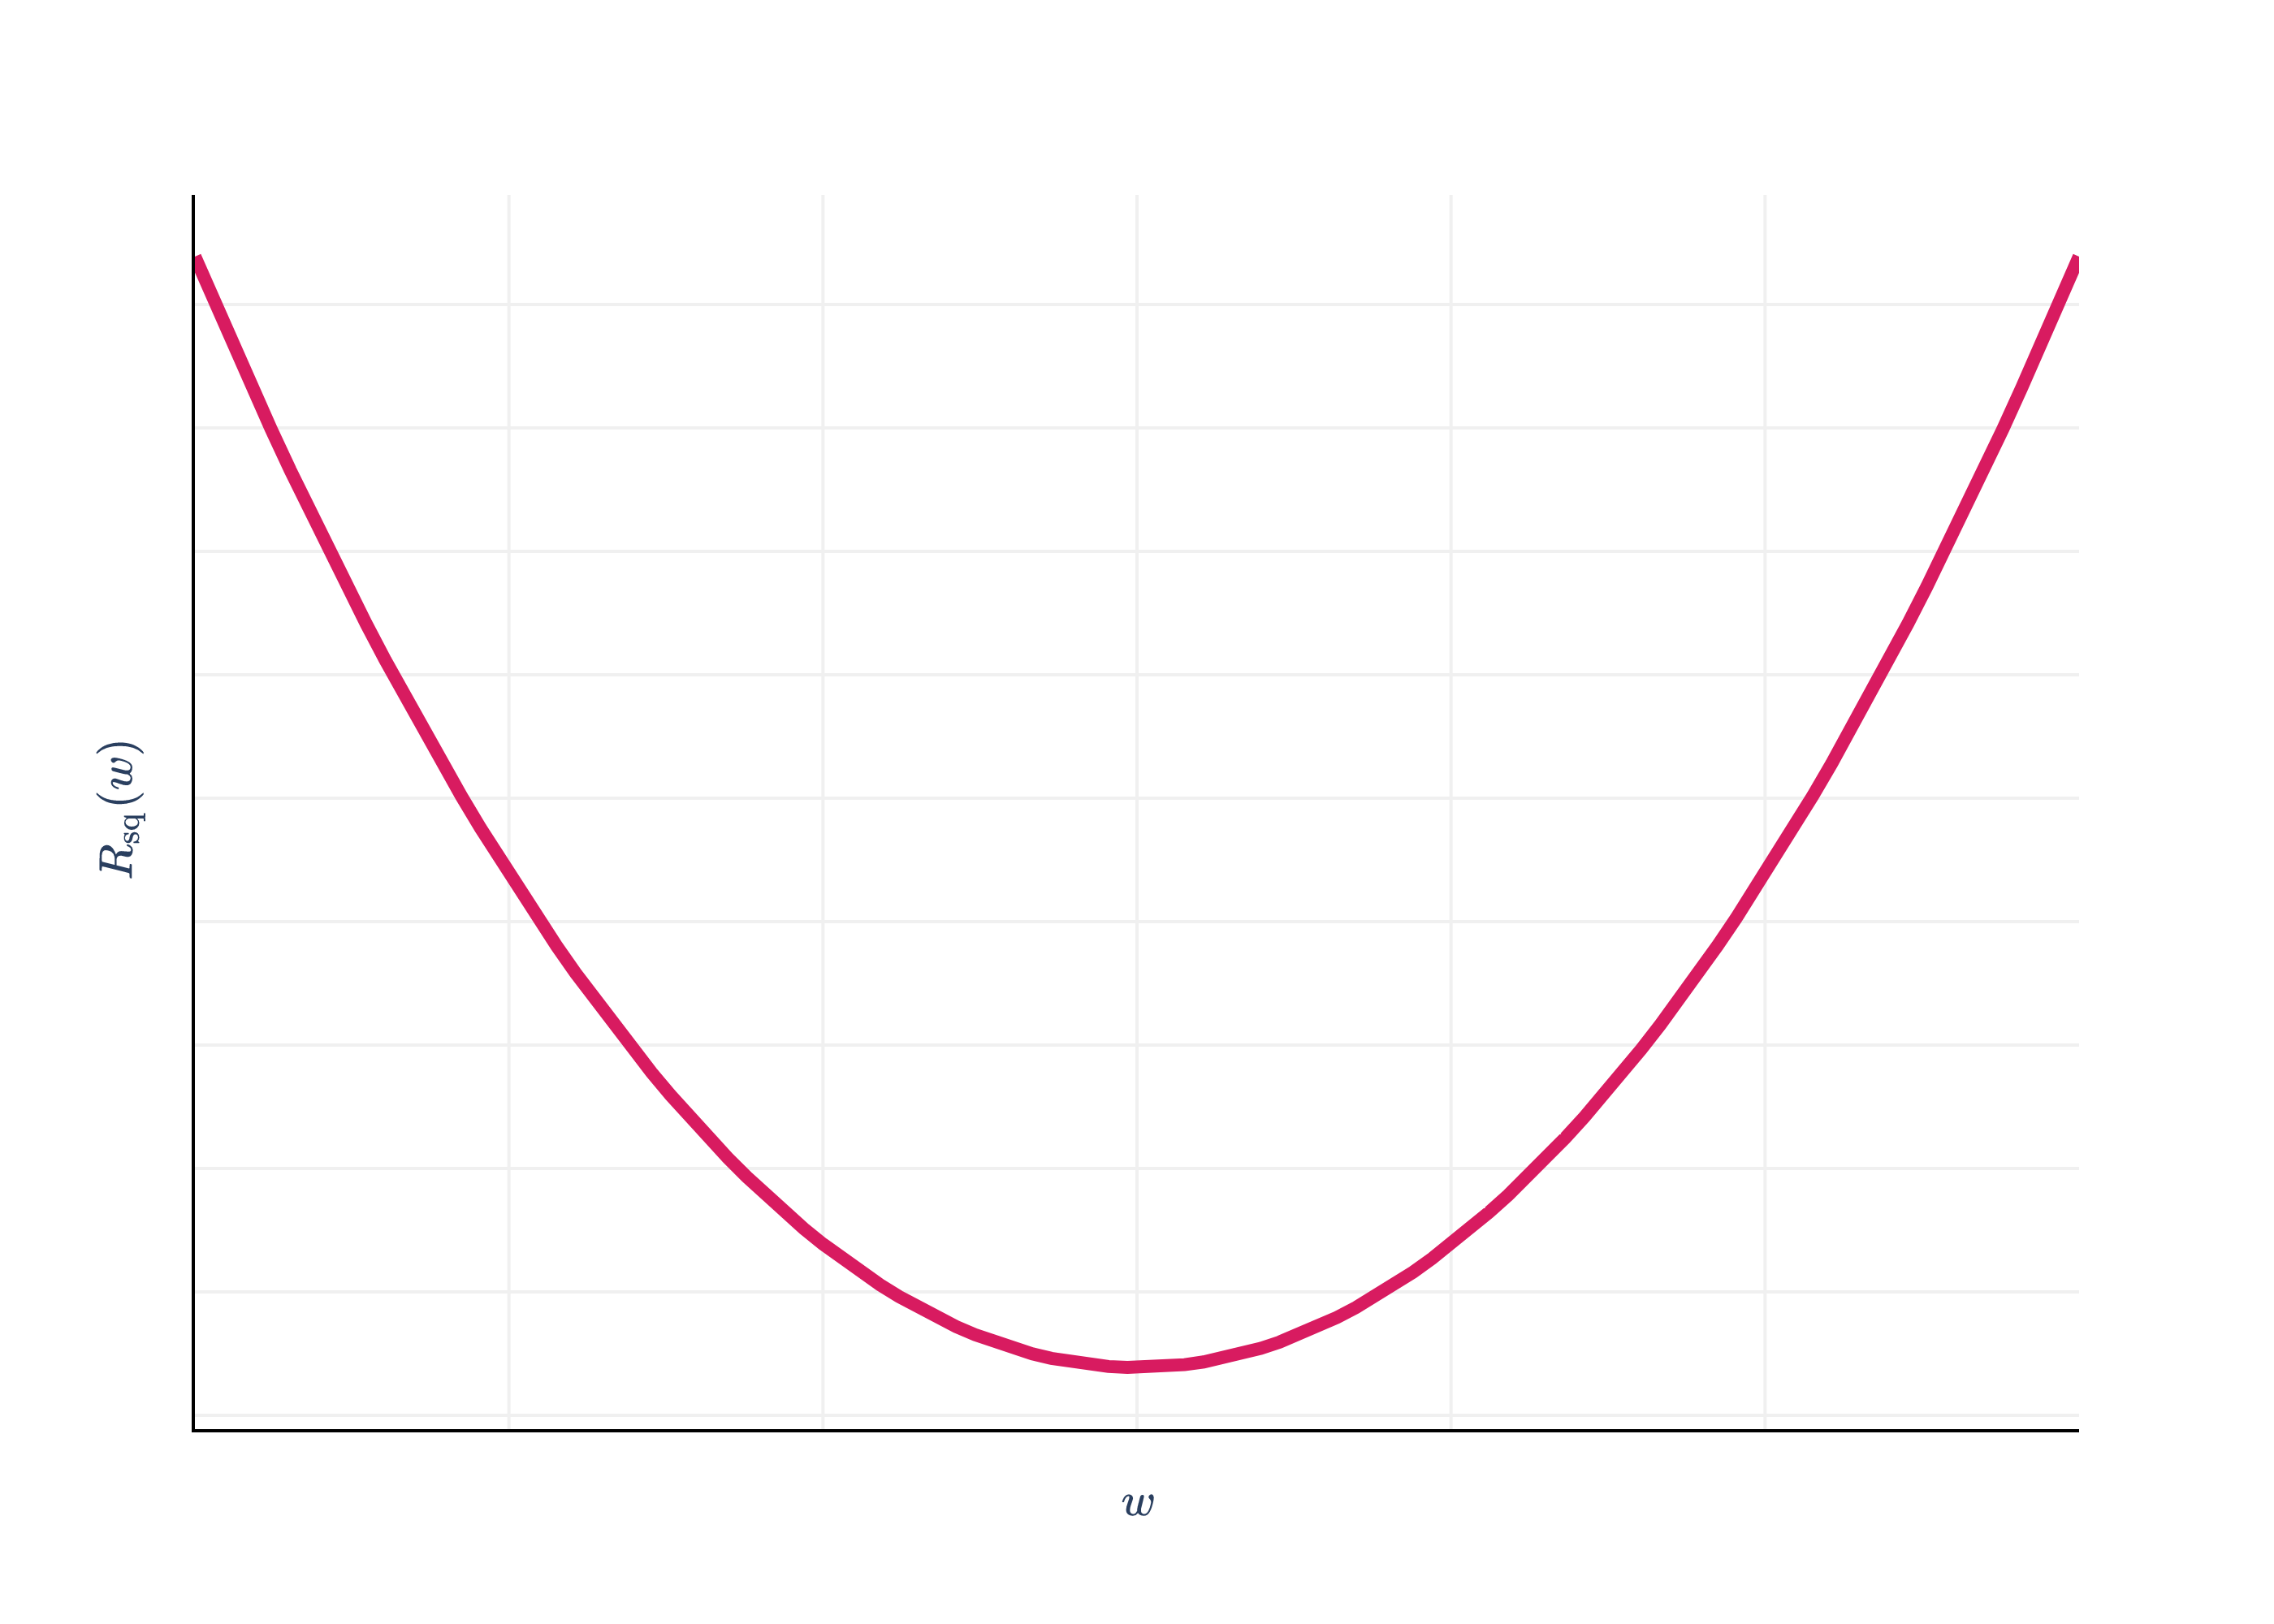

In [306]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('data/commute-times.csv')

f = lambda h: ((72-h)**2 + (90-h)**2 + (61-h)**2 + (85-h)**2 + (92-h)**2) / 5

x = np.linspace(50, 110, 100)
y = np.array([f(h) for h in x])

# Calculate mean and variance
data = np.array([72, 90, 61, 85, 92])
mean = np.mean(data)
variance = np.mean((data - mean) ** 2)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x, 
        y=y, 
        mode='lines', 
        name='Data', 
        line=dict(color='#D81B60', width=4)
    )
)

# Draw a point at the vertex (mean, variance)
# fig.add_trace(
#     go.Scatter(
#         x=[mean],
#         y=[variance],
#         mode='markers+text',
#         marker=dict(color='#D81B60', size=14, symbol='circle'),
#         text=[f"<span style='font-family:Palatino, Palatino Linotype, serif; color:#D81B60'>(mean, variance)</span>"],
#         textposition="top center",
#         showlegend=False
#     )
# )

fig.update_xaxes(
    showticklabels=False,
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    showticklabels=False
)

fig.update_layout(
    xaxis_title=r'$w$',
    yaxis_title=r'$R_\text{sq}(w)$',
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        # color="black"
    ),
    showlegend=False
)

fig.show(renderer='png', scale=4)


$R_\text{sq}(w)$ was a function with just a single input variable ($w$), so the problem of minimizing $R_\text{sq}(w)$ was straightforward, and resembled problems we solved in Calculus 1.

The function $R_\text{sq}(w_0, w_1)$ we're minimizing now has **two** input variables, $w_0$ and $w_1$. In mathematics, sometimes we'll write $R_\text{sq}: \mathbb{R}^2 \to \mathbb{R}$ to say that $R_\text{sq}$ is a function that takes in two real numbers and returns a single real number.

$$R_\text{sq}(w_0, w_1) = \frac{1}{n} \sum_{i=1}^n (y_i - (w_0 + w_1 x_i))^2$$

Remember, we should treat the $x_i$'s and $y_i$'s as constants, as these are known quantities once we're given a dataset.

What does $R_\text{sq}(w_0, w_1)$ even look like? We need three dimensions to visualize it – one axis for $w_0$, one for $w_1$, and one for the output, $R_\text{sq}(w_0, w_1)$.

In [307]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

def slope(x, y):
    # Assume x and y are two Series.
    numerator = ((x - np.mean(x)) * (y - np.mean(y))).sum()
    denominator = ((x - np.mean(x)) ** 2).sum()
    return numerator / denominator

def intercept(x, y):
    return y.mean() - slope(x, y) * x.mean()

df = pd.read_csv('data/commute-times.csv')

w0_star = intercept(df['departure_hour'], df['minutes'])
w1_star = slope(df['departure_hour'], df['minutes'])

def mse(y_actual, y_pred):
    return np.mean((y_actual - y_pred)**2)

def mse_for_departure_model(w):
    w0, w1 = w
    return mse(df['minutes'], w0 + w1 * df['departure_hour'])

num_points = 50 # increase for better resolution, but it will run more slowly. 
uvalues = np.linspace(120, 160, num_points)
vvalues = np.linspace(-13, -3, num_points)
(u, v) = np.meshgrid(uvalues, vvalues)
thetas = np.vstack((u.flatten(), v.flatten()))
MSE = np.array([mse_for_departure_model(t) for t in thetas.T])
loss_surface = go.Surface(
    x=u, y=v, z=np.reshape(MSE, u.shape),
    colorscale='PuRd',
    showscale=False,
    opacity=1,
    hovertemplate="w₀: %{x}<br>w₁: %{y}<br>R(w₀, w₁): %{z}<extra></extra>"
)
minimizer = go.Scatter3d(
    x=[w0_star], y=[w1_star], z=[mse_for_departure_model([w0_star, w1_star])],
    mode='markers', name='optimal parameters',
    marker=dict(size=10, color='gold'),
    hovertemplate="w₀: %{x}<br>w₁: %{y}<br>R(w₀, w₁): %{z}<extra></extra>"
)
fig = go.Figure(data=[loss_surface, minimizer])

fig.update_layout(
    scene=dict(
        xaxis=dict(
            title="w₀",
            backgroundcolor="white",
            gridcolor="#f0f0f0",
            showbackground=True,
            showline=True,
            linecolor="black",
            linewidth=1,
        ),
        yaxis=dict(
            title="w₁",
            backgroundcolor="white",
            gridcolor="#f0f0f0",
            showbackground=True,
            showline=True,
            linecolor="black",
            linewidth=1,
        ),
        zaxis=dict(
            title="R(w₀, w₁)",
            backgroundcolor="white",
            gridcolor="#f0f0f0",
            showbackground=True,
            showline=True,
            linecolor="black",
            linewidth=1,
        ),
        bgcolor="white"
    ),
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=30, r=30, t=30, b=30),
    autosize=True,
    width=600,
    height=400,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    scene_camera=dict(
        eye=dict(x=-1.5, y=1.5, z=1.0)
    ),
)

fig.show(scale=4)

The graph above is called a **loss surface**, even though it's a graph of empirical risk, i.e. average loss, not the loss for a single data point. The plot is interactive, so you should drag it around to get a sense of what it looks like. It looks like a parabola with added depth, similar to how cubes look like squares with added depth. Lighter regions above correspond to low mean squared error, and darker regions correspond to high mean squared error.
<!-- <span style="color:red; font-weight:bold;">Red</span> regions correspond to high mean squared error, and <span style="color:blue; font-weight:bold;">blue</span> regions correspond to low mean squared error. -->

Think of the "floor" of the graph – in other words, the $w_0$-$w_1$ plane – as all the set of possible combinations of intercept and slope. The height of the surface at any point $(w_0, w_1)$ is the mean squared error of the hypothesis $h(x_i) = w_0 + w_1 x_i$ on the commute times dataset.

Our goal is to find the combination of $w_0$ and $w_1$ that get us to the bottom of the surface, marked by the <span style="color:gold; font-weight:bold;">gold point</span> in the plot. This will involve calculus and derivatives, but we'll need to extend our single variable approach: we'll need to take **partial derivatives** with respect to $w_0$ and $w_1$. [Chapter 2.2](02-partial-derivatives.ipynb) is a detour that describes how these work; in [Chapter 2.3](03-finding-optimal-parameters.ipynb), we'll use them to find the optimal parameters.

---

## A Preview

Just so you have them, though, here's what we'll end up finding:

$$\boxed{w_1^* = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}, \qquad w_0^* = \bar{y} - w_1^* \bar{x}}$$

These are formulas that describe the optimal slope, $w_1^*$, and intercept, $w_0^*$, for the simple linear regression model, given a dataset $(x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)$. They are chosen to minimize mean squared error. On our commute times dataset, the resulting line looks like this:

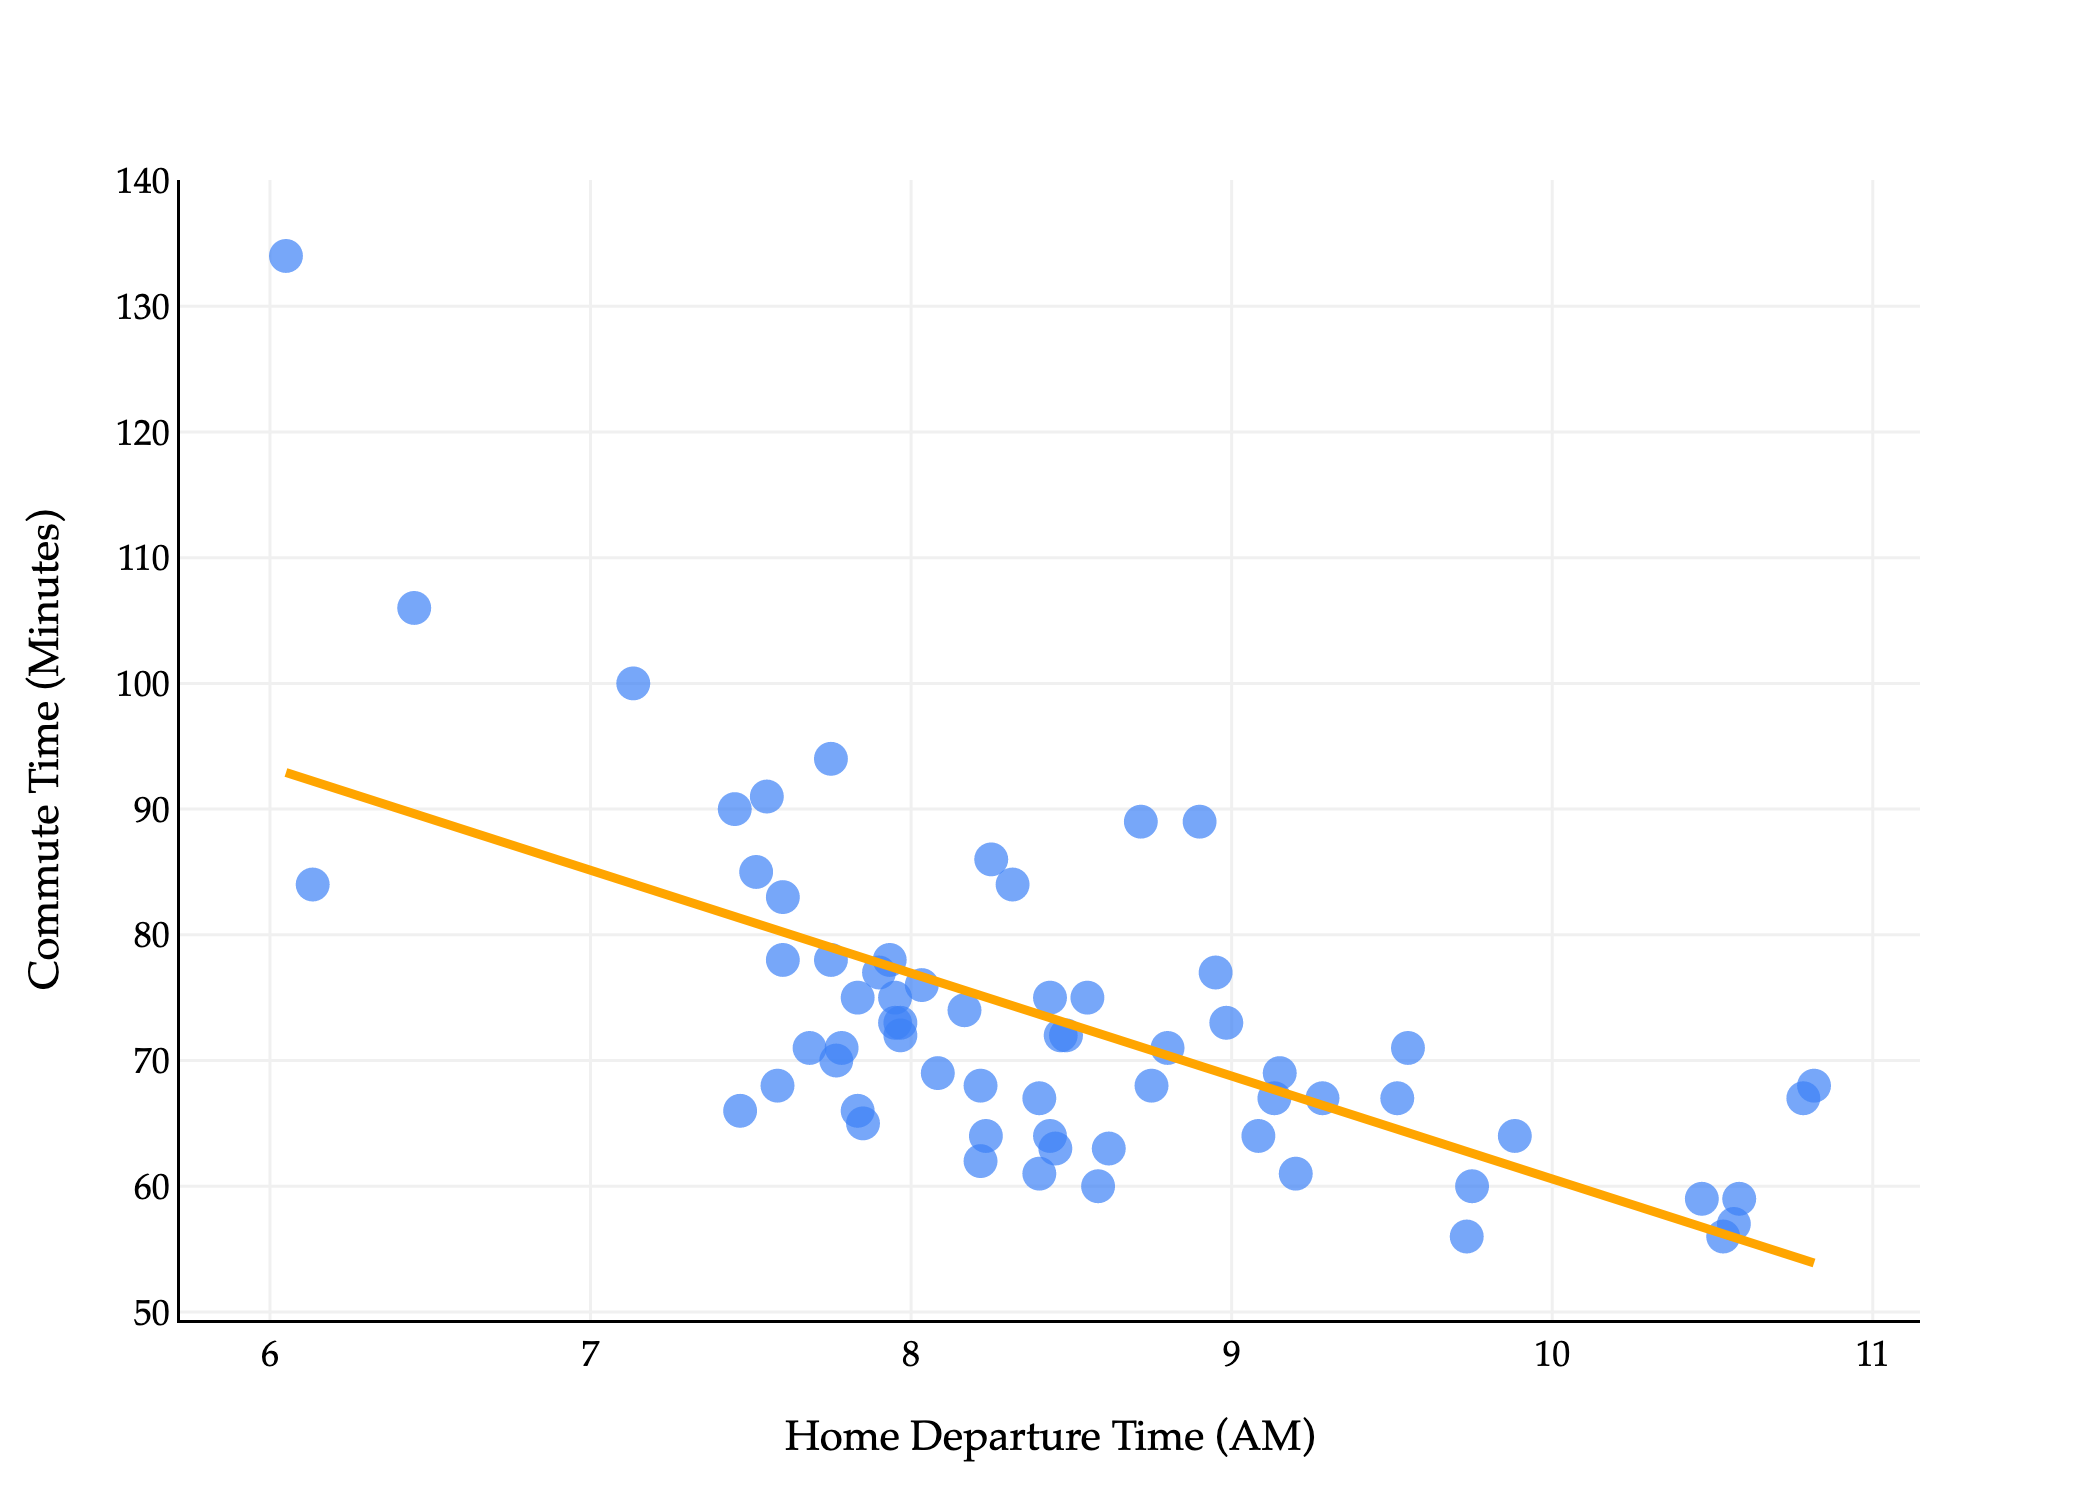

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('data/commute-times.csv')

# Compute means
x = df['departure_hour'].values
y = df['minutes'].values
x_bar = np.mean(x)
y_bar = np.mean(y)

# Compute slope (w1) and intercept (w0) using the closed-form solution
w1 = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar) ** 2)
w0 = y_bar - w1 * x_bar

# Prepare regression line points
x_line = np.array([x.min(), x.max()])
y_line = w0 + w1 * x_line

# Create scatter plot
fig = px.scatter(
    df,
    x='departure_hour',
    y='minutes',
    size=np.ones(len(df)) * 50,
    size_max=8
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0)

# Add regression line in orange
fig.add_traces(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    line=dict(color='orange', width=3),
    name='Regression Line'
))

fig.update_xaxes(
    title='Home Departure Time (AM)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    title='Commute Time (Minutes)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    showlegend=False
)
fig.show(renderer='png', scale=3)